### Import Liberary

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Import Kaggle dataset

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iabdulw/ecommerce-customer-data")

print("Path to dataset files:", path)

Path to dataset files: /home/md-naim/.cache/kagglehub/datasets/iabdulw/ecommerce-customer-data/versions/1


In [25]:
from pathlib import Path

csv_files = list(Path(path).rglob("*.csv"))


In [26]:

data = pd.read_csv(csv_files[0])
data.head()

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


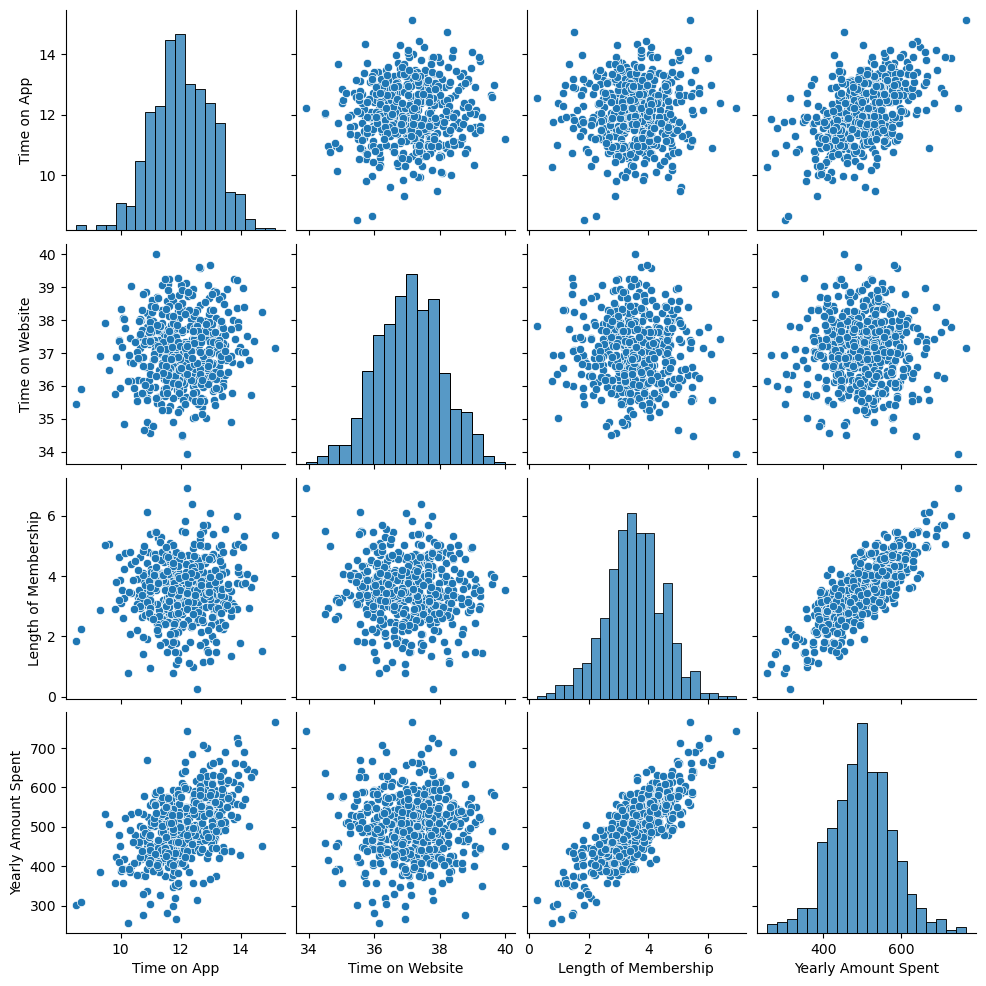

In [28]:
sns.pairplot(
    data=data
)

In [45]:
data.columns = data.columns.str.strip()

data.drop(
    columns=["Email", "Address", "Avatar"],
    errors="ignore",
    inplace=True
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time on App           500 non-null    float64
 1   Time on Website       500 non-null    float64
 2   Length of Membership  500 non-null    float64
 3   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


In [46]:
features = data.drop(
    columns=['Yearly Amount Spent']
)

In [47]:
target = data['Yearly Amount Spent']

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train,X_test,y_train,y_test = train_test_split(
    features, 
    target, 
    train_size=.80,
    random_state=42 
)

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
model.coef_

array([37.99274285,  0.53471024, 62.76998035])

In [53]:
model.intercept_

np.float64(-199.8768547850985)

<Axes: xlabel='Yearly Amount Spent'>

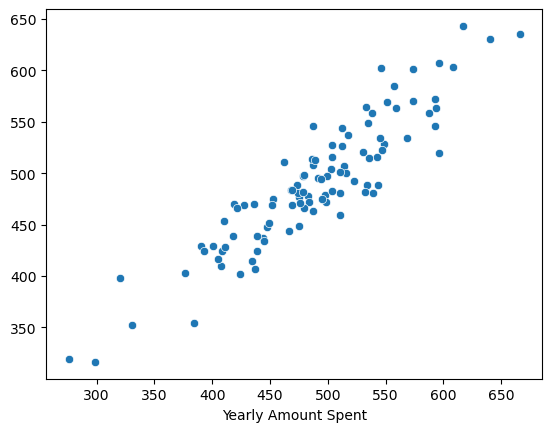

In [54]:
prediction = model.predict(X_test)
sns.scatterplot(
    x=y_test,
    y=prediction
)

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

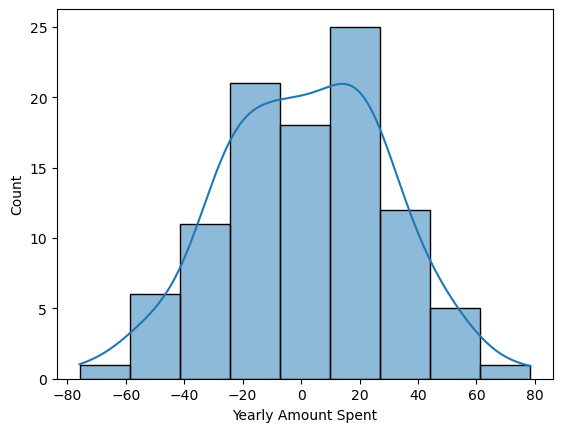

In [57]:
sns.histplot(
    x=prediction-y_test,
    kde = True
)